In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

# ══════════════════════════════════════════════════════════════════════════════
# Constants
# ══════════════════════════════════════════════════════════════════════════════
DATA_ROOT = {
    "TOP":    "/home/frankie/WCIS/FLASH-ADC-CHARACTERIZATION/data_FINAL/TOP",
    "BOTTOM": "/home/frankie/WCIS/FLASH-ADC-CHARACTERIZATION/data_FINAL/BOTTOM",
}

POWER_MODES  = ["HPM", "RPM", "LPM"]
FS_STR_LIST  = ["500k", "1M", "2M", "3M", "4M", "5M", "6M"]
FS_LIST      = [500e3,  1e6,  2e6,  3e6,  4e6,  5e6,  6e6]
J_LIST       = [1637,   819,  409,  273,  205,  163,  135]

BUFFER_SIZE     = 8192
REF_HI          = 2.8
REF_LO          = 0.8
SHUNT_RESISTANCE = 1.02

SHUNT_VOLTAGE = {
    "HPM": {"500k": 4.62e-3, "1M": 4.98e-3, "2M": 5.62e-3, "3M": 6.16e-3, "4M": 6.74e-3, "5M": 7.32e-3, "6M": 0},
    "RPM": {"500k": 3.25e-3, "1M": 3.60e-3, "2M": 4.20e-3, "3M": 4.80e-3, "4M": 5.38e-3, "5M": 5.93e-3, "6M": 0},
    "LPM": {"500k": 2.50e-3, "1M": 2.89e-3, "2M": 3.52e-3, "3M": 3.96e-3, "4M": 4.39e-3, "5M": 4.98e-3, "6M": 0},
}

POWER_W = {
    pm: {fs: (v**2 / SHUNT_RESISTANCE) for fs, v in fs_dict.items()}
    for pm, fs_dict in SHUNT_VOLTAGE.items()
}

hann_window = np.hanning(BUFFER_SIZE)

# ══════════════════════════════════════════════════════════════════════════════
# Helper functions
# ══════════════════════════════════════════════════════════════════════════════
def alias(harmonic_freq, fs, N):
    a = harmonic_freq % fs
    if a > fs / 2:
        a = fs - a
    return int(round(a / fs * N))


def tabei_ueda(fft_full, fft_mag, N, window):
    """Returns (A, fx, Po) — amplitude (V), fractional bin, phase (cycles)."""
    fft_pos = fft_mag[:N // 2]
    kmax = np.argmax(fft_pos[1:]) + 1

    if fft_mag[kmax - 1] > fft_mag[kmax + 1]:
        r  = fft_mag[kmax - 1] / fft_mag[kmax]
        fx = kmax + (1.0 - 2.0 * r) / (1.0 + r)
    else:
        r  = fft_mag[kmax + 1] / fft_mag[kmax]
        fx = kmax - (1.0 - 2.0 * r) / (1.0 + r)

    dx   = fx - kmax
    dy   = np.pi * dx
    sinc = (dy / np.sin(dy)) if abs(dx) > 1e-10 else 1.0
    CG   = np.sum(window) / N

    A  = (-fft_mag[kmax] / N) * sinc * (dx - 1.0) * (dx + 1.0) / CG * 2.0
    Po = (1 / (2 * np.pi)) * np.angle(fft_full[kmax] * np.exp(-1j * dy))
    return A, fx, Po


# ══════════════════════════════════════════════════════════════════════════════
# Load raw data for both channels
# ══════════════════════════════════════════════════════════════════════════════
def load_channel(root_path):
    raw_dfs = {pm: pd.DataFrame() for pm in POWER_MODES}
    for pm_folder in os.listdir(root_path):
        pm_path = os.path.join(root_path, pm_folder)
        if os.path.isdir(pm_path) and pm_folder in POWER_MODES:
            for fs_folder in os.listdir(pm_path):
                fs_path = os.path.join(pm_path, fs_folder)
                if os.path.isdir(fs_path):
                    for csv_file in glob.glob(os.path.join(fs_path, "*.csv")):
                        df = pd.read_csv(csv_file)
                        for k, col in enumerate(df.columns):
                            raw_dfs[pm_folder][fs_folder + str(k)] = df[col]
    return raw_dfs


print("Loading TOP channel...")
raw_dfs_top = load_channel(DATA_ROOT["TOP"])
print("Loading BOTTOM channel...")
raw_dfs_bot = load_channel(DATA_ROOT["BOTTOM"])
print("Data loaded.\n")


# ══════════════════════════════════════════════════════════════════════════════
# Core characterization function — runs on one channel's raw_dfs
# ══════════════════════════════════════════════════════════════════════════════
def characterize_channel(raw_dfs, channel_name):
    results = []

    for pm in POWER_MODES:
        for fs_str, fs in zip(FS_STR_LIST, FS_LIST):

            test_cols = [c for c in raw_dfs[pm].columns if c.startswith(fs_str)]
            if not test_cols:
                continue

            signal_pow_list = []
            noise_pow_list  = []
            harm_pow_list   = []
            noise_fft_mag   = None

            for col in test_cols:
                waveform_code = np.array(raw_dfs[pm][col].to_list())
                signal = (waveform_code / 255) * 2.0 - 1.0
                signal = signal - np.mean(signal)
                N = len(signal)

                if N != BUFFER_SIZE:
                    # Trim or skip if buffer size mismatch
                    if N > BUFFER_SIZE:
                        signal = signal[:BUFFER_SIZE]
                        N = BUFFER_SIZE
                    else:
                        print(f"  Skip {channel_name}/{pm}/{fs_str}/{col} — short buffer ({N})")
                        continue

                if np.std(signal) < 0.01:
                    print(f"  Skip {channel_name}/{pm}/{fs_str}/{col} — flat signal")
                    continue

                windowed = signal * hann_window
                fft_full = np.fft.fft(windowed)
                fft_mag  = np.abs(fft_full)

                A, fx, Po = tabei_ueda(fft_full, fft_mag, N, hann_window)
                f_est = fx * (fs / N)

                if not np.isfinite(A) or not np.isfinite(f_est) or A <= 0:
                    print(f"  Skip {channel_name}/{pm}/{fs_str}/{col} — T&U failed")
                    continue

                t     = np.arange(N) / fs
                ideal = A * np.cos(2 * np.pi * f_est * t + 2 * np.pi * Po)
                noise = signal - ideal

                signal_pow_list.append(np.mean(ideal ** 2))
                noise_pow_list.append(np.mean(noise ** 2))

                CG = np.sum(hann_window) / N
                noise_fft_mag = np.abs(np.fft.fft(noise * hann_window)) / N / CG * 2

                harm_pows = []
                for k in range(2, 11):
                    idx = alias(k * f_est, fs, N)
                    if 0 < idx < N // 2:
                        harm_pows.append(noise_fft_mag[idx] ** 2 / 2)
                harm_pow_list.append(np.sum(harm_pows))

            if not signal_pow_list:
                print(f"  WARNING: no valid captures for {channel_name}/{pm}/{fs_str}")
                continue

            avg_signal_pow = np.mean(signal_pow_list)
            avg_noise_pow  = np.mean(noise_pow_list)
            avg_harm_pow   = np.mean(harm_pow_list)

            rms_signal = np.sqrt(avg_signal_pow)
            rms_noise  = np.sqrt(avg_noise_pow)
            rms_harm   = np.sqrt(avg_harm_pow)

            SINAD = 20 * np.log10(rms_signal / rms_noise)
            ENOB  = (SINAD - 1.76) / 6.02

            rms_noise_only = np.sqrt(max(avg_noise_pow - avg_harm_pow, 1e-30))
            SNR  = 20 * np.log10(rms_signal / rms_noise_only)
            THD  = 20 * np.log10(rms_harm / rms_signal) if rms_harm > 0 else -np.inf

            sfdr_mag = noise_fft_mag.copy()
            sfdr_mag[:3] = 0
            SFDR = -20 * np.log10(np.max(sfdr_mag[:N // 2]) / (rms_signal * np.sqrt(2)))

            DR    = -20 * np.log10(rms_noise / 1.0)
            power = POWER_W[pm][fs_str]
            FOMw  = power / (2 ** ENOB * fs)

            results.append({
                "Channel":       channel_name,
                "Power Mode":    pm,
                "Fs":            fs_str,
                "ENOB (bits)":   round(ENOB, 2),
                "SNR (dB)":      round(SNR, 2),
                "SINAD (dB)":    round(SINAD, 2),
                "THD (dBFS)":    round(THD, 2),
                "SFDR (dBFS)":   round(SFDR, 2),
                "DR (dBFS)":     round(DR, 2),
                "Power (W)":     power,
                "FOMw (J/step)": FOMw,
            })

            print(f"  {channel_name}/{pm}/{fs_str}: ENOB={ENOB:.2f} bits, "
                  f"SINAD={SINAD:.2f} dB, SNR={SNR:.2f} dB, THD={THD:.2f} dBFS, "
                  f"captures={len(signal_pow_list)}")

    return pd.DataFrame(results)


# ══════════════════════════════════════════════════════════════════════════════
# Run characterization for both channels
# ══════════════════════════════════════════════════════════════════════════════
print("─" * 60)
print("Characterizing TOP channel...")
print("─" * 60)
df_top = characterize_channel(raw_dfs_top, "TOP")

print()
print("─" * 60)
print("Characterizing BOTTOM channel...")
print("─" * 60)
df_bot = characterize_channel(raw_dfs_bot, "BOTTOM")

# Combined dataframe
df_all = pd.concat([df_top, df_bot], ignore_index=True)

print("\n══ Results ══")
print(df_all.to_string(index=False))




Loading TOP channel...


/tmp/ipykernel_61862/1309322413.py:84: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw_dfs[pm_folder][fs_folder + str(k)] = df[col]


Loading BOTTOM channel...


/tmp/ipykernel_61862/1309322413.py:84: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  raw_dfs[pm_folder][fs_folder + str(k)] = df[col]


Data loaded.

────────────────────────────────────────────────────────────
Characterizing TOP channel...
────────────────────────────────────────────────────────────
  TOP/HPM/500k: ENOB=4.38 bits, SINAD=28.14 dB, SNR=33.28 dB, THD=-29.73 dBFS, captures=100
  TOP/HPM/1M: ENOB=4.51 bits, SINAD=28.93 dB, SNR=34.04 dB, THD=-30.54 dBFS, captures=100
  TOP/HPM/2M: ENOB=4.51 bits, SINAD=28.92 dB, SNR=33.34 dB, THD=-30.87 dBFS, captures=100
  TOP/HPM/3M: ENOB=4.08 bits, SINAD=26.29 dB, SNR=30.41 dB, THD=-28.42 dBFS, captures=100
  TOP/HPM/4M: ENOB=3.87 bits, SINAD=25.03 dB, SNR=27.76 dB, THD=-28.34 dBFS, captures=100
  TOP/HPM/5M: ENOB=-0.10 bits, SINAD=1.15 dB, SNR=1.88 dB, THD=-9.27 dBFS, captures=100
  TOP/RPM/500k: ENOB=4.52 bits, SINAD=28.97 dB, SNR=33.96 dB, THD=-30.63 dBFS, captures=100
  TOP/RPM/1M: ENOB=4.63 bits, SINAD=29.62 dB, SNR=34.11 dB, THD=-31.53 dBFS, captures=100
  TOP/RPM/2M: ENOB=4.08 bits, SINAD=26.30 dB, SNR=29.53 dB, THD=-29.10 dBFS, captures=100
  TOP/RPM/3M: ENOB=3.8

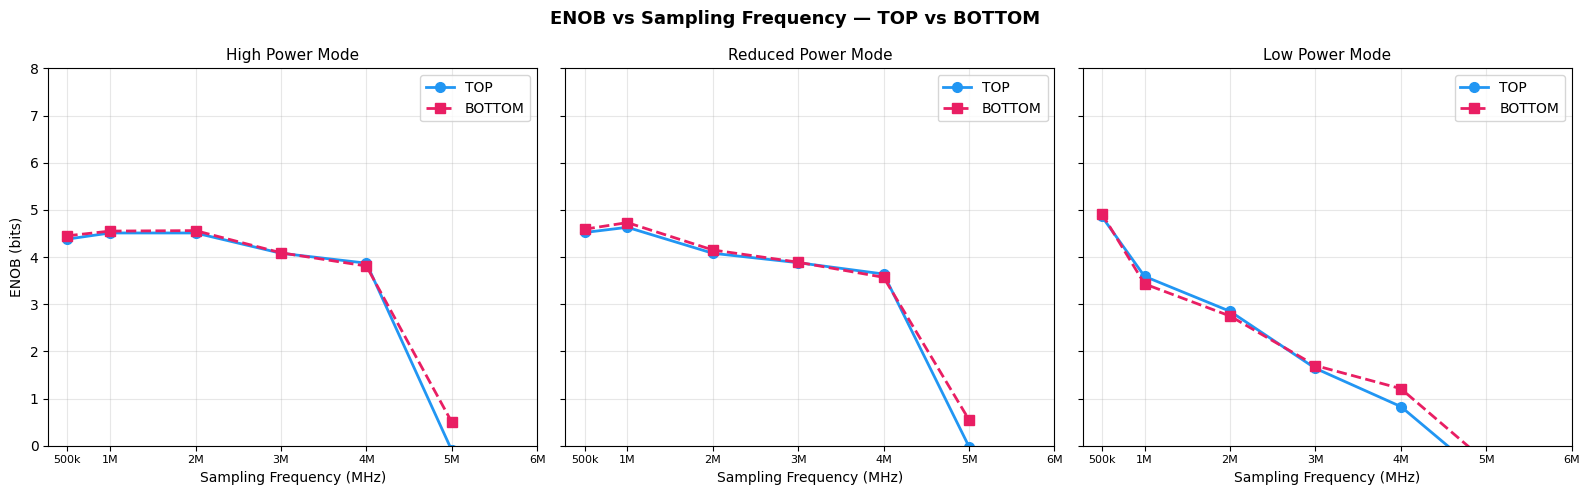

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Plot 1 — ENOB vs Fs: TOP vs BOTTOM, per power mode (2x3 grid)
# ══════════════════════════════════════════════════════════════════════════════
channel_colors  = {"TOP": "#2196F3", "BOTTOM": "#E91E63"}
channel_markers = {"TOP": "o",       "BOTTOM": "s"}
channel_ls      = {"TOP": "-",       "BOTTOM": "--"}
pm_titles       = {"HPM": "High Power Mode", "RPM": "Reduced Power Mode", "LPM": "Low Power Mode"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
fig.suptitle("ENOB vs Sampling Frequency — TOP vs BOTTOM", fontsize=13, fontweight="bold")

for ax, pm in zip(axes, POWER_MODES):
    for ch in ["TOP", "BOTTOM"]:
        sub = df_all[(df_all["Channel"] == ch) & (df_all["Power Mode"] == pm)]
        if sub.empty:
            continue
        fs_vals   = [FS_LIST[FS_STR_LIST.index(fs)] / 1e6 for fs in sub["Fs"]]
        enob_vals = sub["ENOB (bits)"].values
        ax.plot(fs_vals, enob_vals,
                color=channel_colors[ch],
                marker=channel_markers[ch],
                linestyle=channel_ls[ch],
                linewidth=2, markersize=7,
                label=ch)

    ax.set_title(pm_titles[pm], fontsize=11)
    ax.set_xlabel("Sampling Frequency (MHz)")
    ax.set_xticks([f / 1e6 for f in FS_LIST])
    ax.set_xticklabels(FS_STR_LIST, fontsize=8)
    ax.set_ylim(0, 8)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("ENOB (bits)")
plt.tight_layout()
plt.savefig("enob_top_vs_bottom.png", dpi=150)
plt.show()




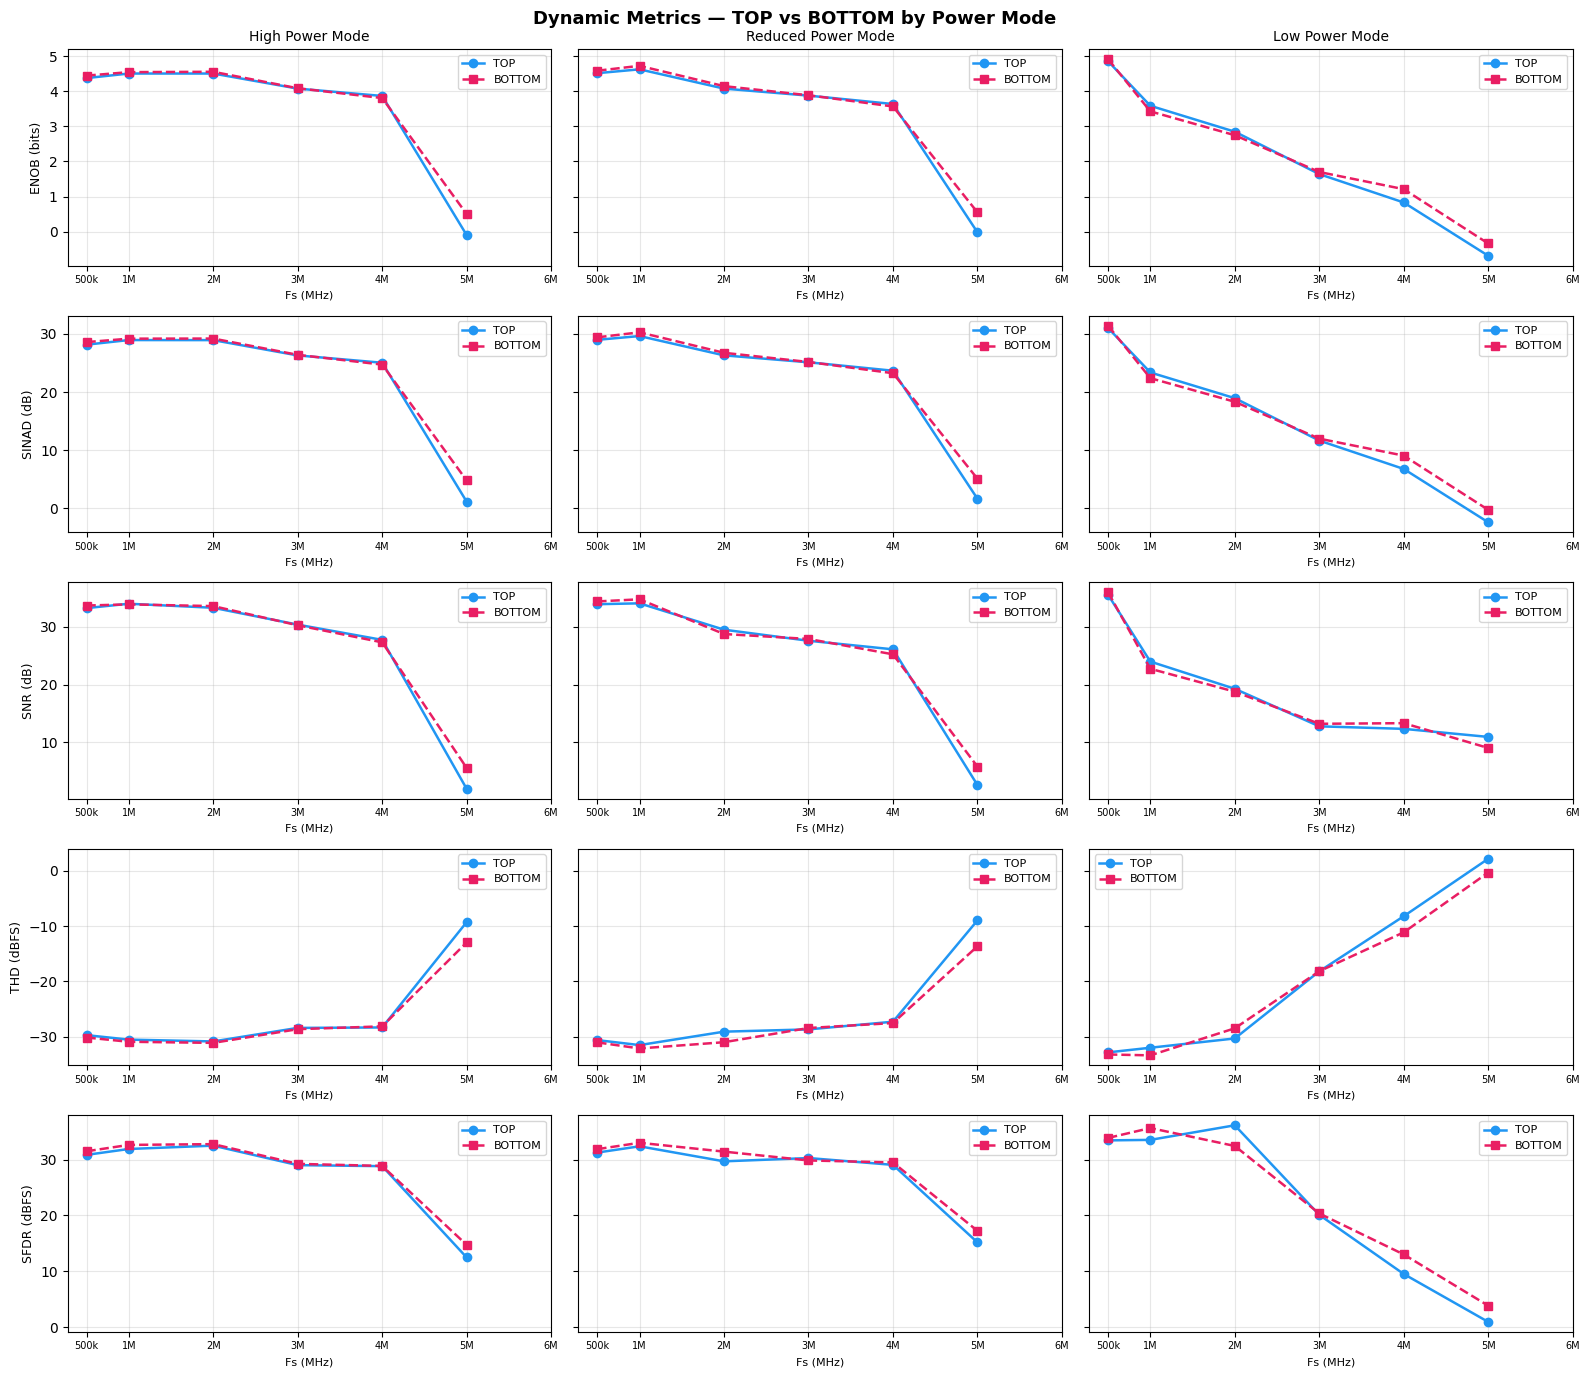

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Plot 2 — SINAD, SNR, THD side-by-side for a chosen pm/fs
# ══════════════════════════════════════════════════════════════════════════════
METRICS = ["ENOB (bits)", "SINAD (dB)", "SNR (dB)", "THD (dBFS)", "SFDR (dBFS)"]

fig, axes = plt.subplots(len(METRICS), 3, figsize=(16, 14), sharey="row")
fig.suptitle("Dynamic Metrics — TOP vs BOTTOM by Power Mode", fontsize=13, fontweight="bold")

for col_idx, pm in enumerate(POWER_MODES):
    for row_idx, metric in enumerate(METRICS):
        ax = axes[row_idx, col_idx]
        for ch in ["TOP", "BOTTOM"]:
            sub = df_all[(df_all["Channel"] == ch) & (df_all["Power Mode"] == pm)]
            if sub.empty:
                continue
            fs_vals     = [FS_LIST[FS_STR_LIST.index(fs)] / 1e6 for fs in sub["Fs"]]
            metric_vals = sub[metric].values
            ax.plot(fs_vals, metric_vals,
                    color=channel_colors[ch],
                    marker=channel_markers[ch],
                    linestyle=channel_ls[ch],
                    linewidth=1.8, markersize=6,
                    label=ch)

        if row_idx == 0:
            ax.set_title(pm_titles[pm], fontsize=10)
        if col_idx == 0:
            ax.set_ylabel(metric, fontsize=9)
        ax.set_xlabel("Fs (MHz)", fontsize=8)
        ax.set_xticks([f / 1e6 for f in FS_LIST])
        ax.set_xticklabels(FS_STR_LIST, fontsize=7)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("metrics_top_vs_bottom.png", dpi=150)
plt.show()




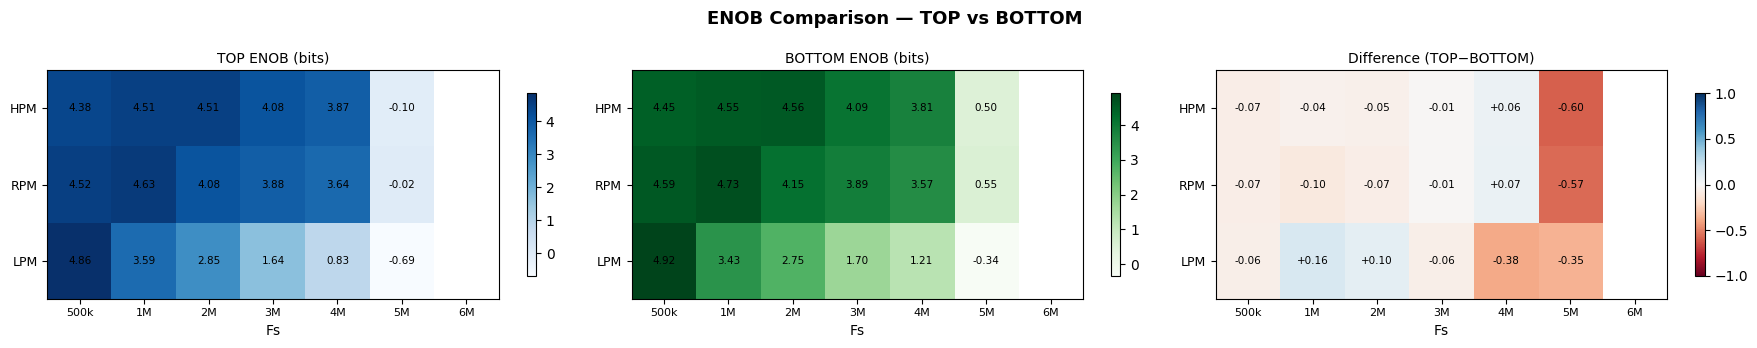

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Plot 3 — ENOB difference (TOP - BOTTOM) heatmap
# ══════════════════════════════════════════════════════════════════════════════
# Build pivot tables
def make_pivot(df, channel, metric="ENOB (bits)"):
    sub = df[df["Channel"] == channel].copy()
    return sub.pivot(index="Power Mode", columns="Fs", values=metric).reindex(
        index=POWER_MODES, columns=FS_STR_LIST
    )

pivot_top = make_pivot(df_all, "TOP")
pivot_bot = make_pivot(df_all, "BOTTOM")
pivot_diff = pivot_top - pivot_bot  # positive = TOP better

fig, axes = plt.subplots(1, 3, figsize=(18, 3.5))
fig.suptitle("ENOB Comparison — TOP vs BOTTOM", fontsize=13, fontweight="bold")

for ax, (data, title, cmap, fmt) in zip(axes, [
    (pivot_top,  "TOP ENOB (bits)",        "Blues",  ".2f"),
    (pivot_bot,  "BOTTOM ENOB (bits)",     "Greens", ".2f"),
    (pivot_diff, "Difference (TOP−BOTTOM)", "RdBu",  "+.2f"),
]):
    im = ax.imshow(data.values.astype(float), cmap=cmap, aspect="auto",
                   vmin=(None if "Diff" not in title else -1),
                   vmax=(None if "Diff" not in title else  1))
    ax.set_xticks(range(len(FS_STR_LIST)))
    ax.set_xticklabels(FS_STR_LIST, fontsize=8)
    ax.set_yticks(range(len(POWER_MODES)))
    ax.set_yticklabels(POWER_MODES, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Fs")

    for i in range(len(POWER_MODES)):
        for j in range(len(FS_STR_LIST)):
            val = data.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, format(val, fmt), ha="center", va="center",
                        fontsize=7.5, color="black")

    plt.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.savefig("enob_heatmap_top_vs_bottom.png", dpi=150)
plt.show()




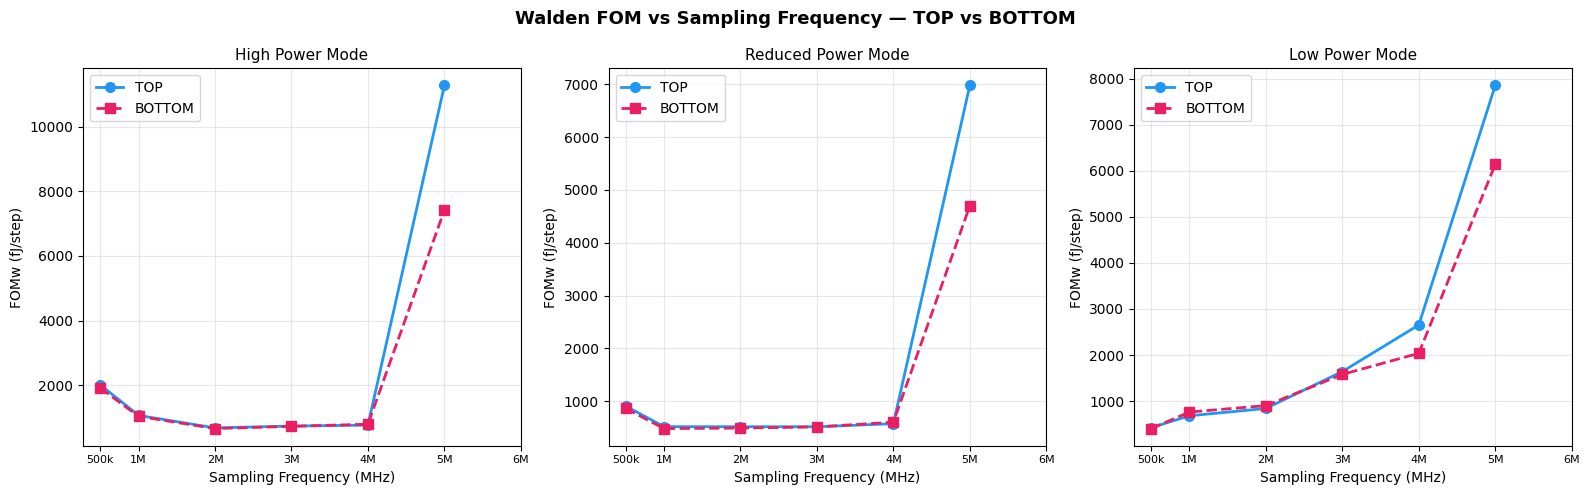

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# Plot 4 — FOMw vs Fs: TOP vs BOTTOM
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Walden FOM vs Sampling Frequency — TOP vs BOTTOM", fontsize=13, fontweight="bold")

for ax, pm in zip(axes, POWER_MODES):
    for ch in ["TOP", "BOTTOM"]:
        sub = df_all[(df_all["Channel"] == ch) & (df_all["Power Mode"] == pm)]
        if sub.empty:
            continue
        fs_vals  = [FS_LIST[FS_STR_LIST.index(fs)] / 1e6 for fs in sub["Fs"]]
        fom_vals = sub["FOMw (J/step)"].values * 1e15  # convert to fJ/step
        ax.plot(fs_vals, fom_vals,
                color=channel_colors[ch],
                marker=channel_markers[ch],
                linestyle=channel_ls[ch],
                linewidth=2, markersize=7,
                label=ch)

    ax.set_title(pm_titles[pm], fontsize=11)
    ax.set_xlabel("Sampling Frequency (MHz)")
    ax.set_xticks([f / 1e6 for f in FS_LIST])
    ax.set_xticklabels(FS_STR_LIST, fontsize=8)
    ax.set_ylabel("FOMw (fJ/step)")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fomw_top_vs_bottom.png", dpi=150)
plt.show()




In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# Summary table — average ENOB per channel per power mode
# ══════════════════════════════════════════════════════════════════════════════
print("\n══ Average ENOB by Channel & Power Mode ══")
summary = df_all.groupby(["Channel", "Power Mode"])["ENOB (bits)"].agg(["mean", "min", "max"]).round(2)
print(summary.to_string())

print("\n══ Full Results Table ══")
print(df_all[[
    "Channel", "Power Mode", "Fs",
    "ENOB (bits)", "SINAD (dB)", "SNR (dB)",
    "THD (dBFS)", "SFDR (dBFS)", "FOMw (J/step)"
]].to_string(index=False))


══ Average ENOB by Channel & Power Mode ══
                    mean   min   max
Channel Power Mode                  
BOTTOM  HPM         3.66  0.50  4.56
        LPM         2.28 -0.34  4.92
        RPM         3.58  0.55  4.73
TOP     HPM         3.54 -0.10  4.51
        LPM         2.18 -0.69  4.86
        RPM         3.46 -0.02  4.63

══ Full Results Table ══
Channel Power Mode   Fs  ENOB (bits)  SINAD (dB)  SNR (dB)  THD (dBFS)  SFDR (dBFS)  FOMw (J/step)
    TOP        HPM 500k         4.38       28.14     33.28      -29.73        30.84   2.007267e-12
    TOP        HPM   1M         4.51       28.93     34.04      -30.54        31.89   1.064521e-12
    TOP        HPM   2M         4.51       28.92     33.34      -30.87        32.49   6.787734e-13
    TOP        HPM   3M         4.08       26.29     30.41      -28.42        29.00   7.356533e-13
    TOP        HPM   4M         3.87       25.03     27.76      -28.34        28.82   7.637082e-13
    TOP        HPM   5M        -0.10    